# **In Silico Identification of Novel Compounds for Insomnia disease.-  Step 3:Compound Clustering**


Similar compounds might bind to the same targets and show similar effects. Based on this similar property principle, compound similarity can be used to build chemical groups via clustering. From such a clustering, a diverse set of compounds can also be selected from a larger set of screening compounds for further experimental testing.
This methodology is based on the TeachOpenCADD Talktorial T005, which provides a standardized workflow for structural similarity analysis using RDKit.

In [20]:
!pip install rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.ML.Cluster import Butina
import numpy as np
import pandas as pd
import time
from tqdm import tqdm
import random
from pathlib import Path
import pandas as pd
import numpy
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
import random
from rdkit.ML.Cluster import Butina
from rdkit import DataStructs

In [21]:
Enamine_dataset_clean=pd.read_csv('../DATA/Enamine_dataset_clean.csv')

In [22]:
Enamine_dataset_clean

,Unnamed: 0.1,Unnamed: 0,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,mol,QED
0,0,0,O=C(NC1=NC(=NS1)C=2C=CC=CC2)C=3C(F)=CC=CC3Br,Z1343597788,378.220,378.220,3.017,-7.078,1,3,54.88,4,https://real.enamine.net/public-enum-files/Z13...,<rdkit.Chem.rdchem.Mol object at 0x16c010ac0>,0.737020
1,1,1,CC1CC=2C=CC=CC2N1C(=O)C=3C=CN(N3)C=4C=CC(F)=CC4,Z391927422,321.349,321.349,3.646,-4.672,0,2,38.13,3,https://real.enamine.net/public-enum-files/Z39...,<rdkit.Chem.rdchem.Mol object at 0x16c010cf0>,0.723111
2,2,2,CC=1C=CC(=CC1)C=2N=NN(CC(=O)NC=3C=CC=CC3OCC(F)...,Z241875964,391.348,391.348,3.408,-5.779,1,5,81.93,7,https://real.enamine.net/public-enum-files/Z24...,<rdkit.Chem.rdchem.Mol object at 0x16c010d60>,0.697764
3,3,3,FC=1C=CC=C(C1)NCC2=NC(=NO2)C3=CC=CO3,Z297575978,259.236,259.236,2.370,-3.198,1,3,64.09,4,https://real.enamine.net/public-enum-files/Z29...,<rdkit.Chem.rdchem.Mol object at 0x16c010dd0>,0.779575
4,4,4,CC=1C=CC=CC1NC(=O)C2CCCN2C3=NC=CS3,Z391936202,287.382,287.382,2.052,-3.989,1,3,45.23,3,https://real.enamine.net/public-enum-files/Z39...,<rdkit.Chem.rdchem.Mol object at 0x16c010e40>,0.943378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43872,45114,53434,CN1C(=NC=2C=CC=CC21)NCC(C=3C=CC=CC3Cl)N4CCOCC4,Z1454327087,370.876,370.876,4.483,-4.083,1,4,42.32,5,https://real.enamine.net/public-enum-files/Z14...,<rdkit.Chem.rdchem.Mol object at 0x32122d230>,0.743019
43873,45115,53435,CCN1C(CN2N=CSC2=O)=NC=3C(F)=CC=CC31,Z1822510276,278.307,278.307,2.708,-2.728,0,3,50.49,3,https://real.enamine.net/public-enum-files/Z18...,<rdkit.Chem.rdchem.Mol object at 0x32122d2a0>,0.734553
43874,45116,53436,COC=1C=C2C(=NC=NC2=CC1F)N[C@@H](C)C=3C=CC(Cl)=CN3,Z1980873798,332.760,332.760,3.301,-4.545,1,5,59.93,4,https://real.enamine.net/public-enum-files/Z19...,<rdkit.Chem.rdchem.Mol object at 0x32122d310>,0.782173
43875,45117,53438,O=C(C=1C=CN(N1)C=2C=CC=CC2)N3CCCCC3CN4C=CC=N4,Z1139313763,335.404,335.404,2.372,-3.120,0,3,55.95,4,https://real.enamine.net/public-enum-files/Z11...,<rdkit.Chem.rdchem.Mol object at 0x32122d380>,0.736556


In [23]:
Enamine_dataset_clean.drop(columns=['mol'], inplace=True)


In [24]:
Enamine_dataset_clean["mol"]=Enamine_dataset_clean["SMILES"].apply(Chem.MolFromSmiles)


##**FINGERPRINT GENERATION**

 To compare molecules, we must convert them into bit-vectors (Fingerprints). I used Morgan Fingerprints (ECFP4), which represent circular atom environments.

In [25]:
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=5)


In [26]:
mol_list = Enamine_dataset_clean["mol"].dropna().tolist()


In [27]:
fingerprints = [rdkit_gen.GetFingerprint(mol) for mol in mol_list]


Now that we generated fingerprints, we move on to the next step: The identification of potential cluster centroids. For this, we define functions to calculate the Tanimoto similarity and distance matrix.

In [28]:
def tanimoto_distance_matrix(fp_list):
    """Calculate distance matrix for fingerprint list"""
    dissimilarity_matrix = []

    for i in range(1, len(fp_list)):

        similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])

        dissimilarity_matrix.extend([1 - x for x in similarities])
    return dissimilarity_matrix

In [29]:
sim = DataStructs.TanimotoSimilarity(fingerprints[0], fingerprints[1])


print(f"Tanimoto similarity: {sim:.2f}, distance: {1-sim:.2f}")

Tanimoto similarity: 0.20, distance: 0.80


##**BUTINA CLUSTERING**

In this part, we cluster the molecules and look at the results.



The Butina algorithm is ideal for chemical datasets as it handles large volumes efficiently and identifies "centroids" (cluster seeds)

In [30]:
def fast_leader_clustering(fingerprints, cutoff=0.6):
    leaders = [] 
    clusters = [] 

    for i, fp in tqdm(enumerate(fingerprints), total=len(fingerprints), desc="Clustering molecules"):
        found = False
        for cluster_idx, leader_idx in enumerate(leaders):
            sim = DataStructs.TanimotoSimilarity(fp, fingerprints[leader_idx])
            if sim >= cutoff:
                clusters[cluster_idx].append(i)
                found = True
                break
        
        if not found:
            leaders.append(i)
            clusters.append([i])
            
    return clusters

print("Starting clustering process for 40k molecules...")
clusters = fast_leader_clustering(fingerprints, cutoff=0.6)

representative_indices = [cluster[0] for cluster in clusters]
enamine_top_representatives = Enamine_dataset_clean.iloc[representative_indices].copy()

print(f"Clustering complete. {len(clusters)} clusters identified.")

Starting clustering process for 40k molecules...


Clustering molecules: 100%|██████████| 43877/43877 [03:46<00:00, 193.63it/s]


Clustering complete. 7707 clusters identified.


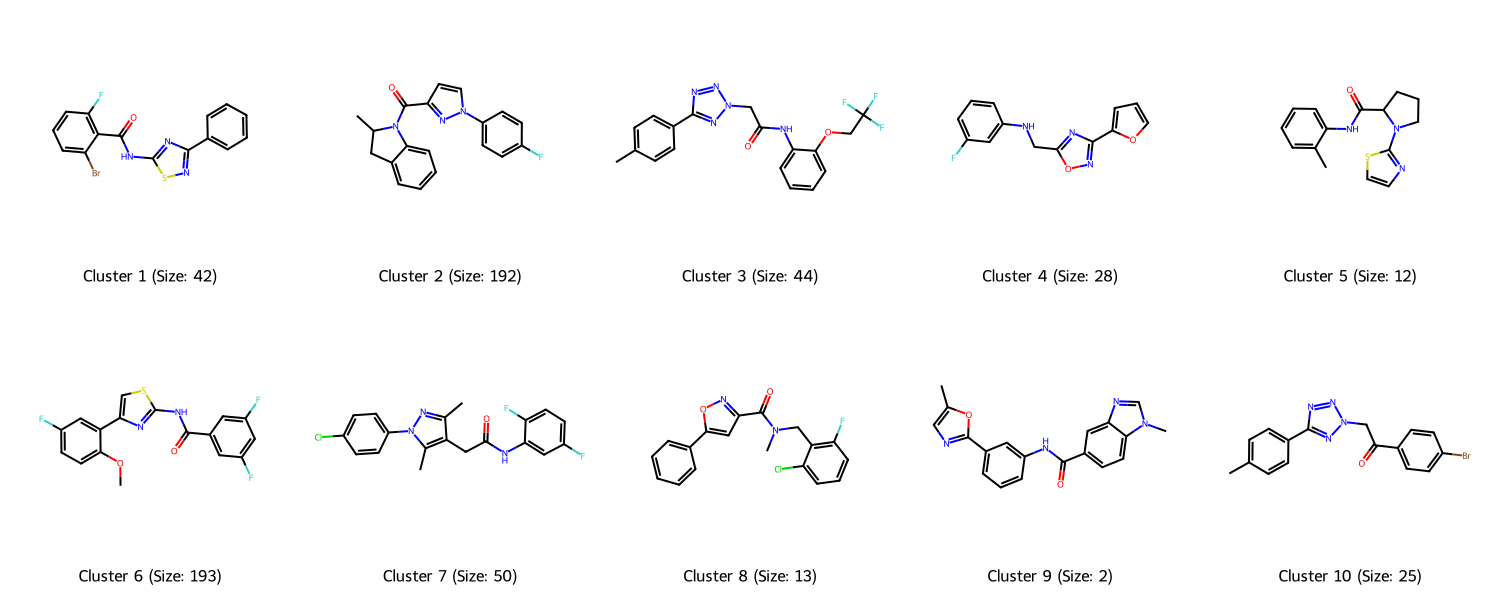

In [31]:
top_centroids = [Enamine_dataset_clean["mol"].iloc[clusters[i][0]] for i in range(10)]
cluster_labels = [f"Cluster {i+1} (Size: {len(clusters[i])})" for i in range(10)]


Draw.MolsToGridImage(
    top_centroids,
    molsPerRow=5,
    legends=cluster_labels,
    subImgSize=(300, 300)
)



In [32]:
n_singletons = sum(1 for c in clusters if len(c) == 1)
percent_singletons = (n_singletons / len(clusters)) * 100



##**REPRESENTATIVE SELECTION**

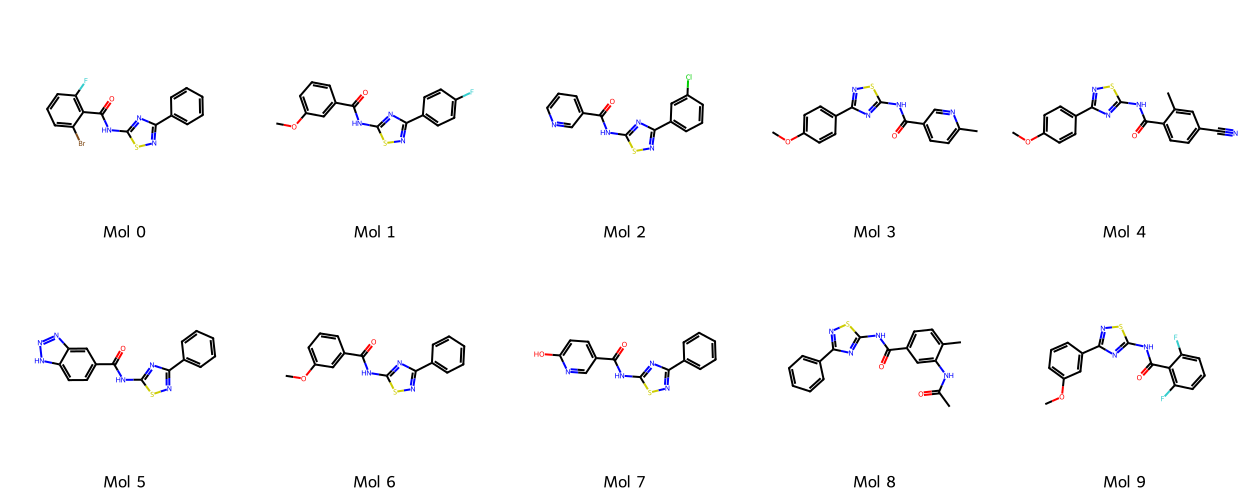

In [33]:

mols_in_largest_cluster = [Enamine_dataset_clean["mol"].iloc[i] for i in clusters[0][:10]]

Draw.MolsToGridImage(
    mols_in_largest_cluster,
    molsPerRow=5,
    legends=[f"Mol {i}" for i in range(10)],
    subImgSize=(250, 250)
)

In [34]:
enamine_representative_set = Enamine_dataset_clean.iloc[representative_indices].copy()


enamine_representative_set["cluster_size"] = [len(c) for c in clusters]



In [35]:
enamine_representative_set

,Unnamed: 0.1,Unnamed: 0,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,QED,mol,cluster_size
0,0,0,O=C(NC1=NC(=NS1)C=2C=CC=CC2)C=3C(F)=CC=CC3Br,Z1343597788,378.220,378.220,3.017,-7.078,1,3,54.88,4,https://real.enamine.net/public-enum-files/Z13...,0.737020,<rdkit.Chem.rdchem.Mol object at 0x1429320a0>,42
1,1,1,CC1CC=2C=CC=CC2N1C(=O)C=3C=CN(N3)C=4C=CC(F)=CC4,Z391927422,321.349,321.349,3.646,-4.672,0,2,38.13,3,https://real.enamine.net/public-enum-files/Z39...,0.723111,<rdkit.Chem.rdchem.Mol object at 0x142931ee0>,192
2,2,2,CC=1C=CC(=CC1)C=2N=NN(CC(=O)NC=3C=CC=CC3OCC(F)...,Z241875964,391.348,391.348,3.408,-5.779,1,5,81.93,7,https://real.enamine.net/public-enum-files/Z24...,0.697764,<rdkit.Chem.rdchem.Mol object at 0x1429325e0>,44
3,3,3,FC=1C=CC=C(C1)NCC2=NC(=NO2)C3=CC=CO3,Z297575978,259.236,259.236,2.370,-3.198,1,3,64.09,4,https://real.enamine.net/public-enum-files/Z29...,0.779575,<rdkit.Chem.rdchem.Mol object at 0x142932650>,28
4,4,4,CC=1C=CC=CC1NC(=O)C2CCCN2C3=NC=CS3,Z391936202,287.382,287.382,2.052,-3.989,1,3,45.23,3,https://real.enamine.net/public-enum-files/Z39...,0.943378,<rdkit.Chem.rdchem.Mol object at 0x1429326c0>,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43861,45103,53417,CC(NC1=NC=2C=CC=CC2S1)C=3C=C(F)C=CC3N4CCC(O)CC4,Z1148790310,371.474,371.474,3.448,-5.330,2,4,48.39,4,https://real.enamine.net/public-enum-files/Z11...,0.705300,<rdkit.Chem.rdchem.Mol object at 0x34ad10430>,1
43863,45105,53420,C1=CC=2CN(CC3=NN=NN3CC=4C=CC=CC4)CCC2S1,Z225167016,311.407,311.407,2.794,-2.490,0,4,46.84,4,https://real.enamine.net/public-enum-files/Z22...,0.741836,<rdkit.Chem.rdchem.Mol object at 0x34ad10510>,1
43872,45114,53434,CN1C(=NC=2C=CC=CC21)NCC(C=3C=CC=CC3Cl)N4CCOCC4,Z1454327087,370.876,370.876,4.483,-4.083,1,4,42.32,5,https://real.enamine.net/public-enum-files/Z14...,0.743019,<rdkit.Chem.rdchem.Mol object at 0x34ad10900>,1
43873,45115,53435,CCN1C(CN2N=CSC2=O)=NC=3C(F)=CC=CC31,Z1822510276,278.307,278.307,2.708,-2.728,0,3,50.49,3,https://real.enamine.net/public-enum-files/Z18...,0.734553,<rdkit.Chem.rdchem.Mol object at 0x34ad10970>,1


In [36]:
enamine_representative_set.drop(columns=['cluster_size'], inplace=True)


In [37]:
enamine_representative_set

,Unnamed: 0.1,Unnamed: 0,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,QED,mol
0,0,0,O=C(NC1=NC(=NS1)C=2C=CC=CC2)C=3C(F)=CC=CC3Br,Z1343597788,378.220,378.220,3.017,-7.078,1,3,54.88,4,https://real.enamine.net/public-enum-files/Z13...,0.737020,<rdkit.Chem.rdchem.Mol object at 0x1429320a0>
1,1,1,CC1CC=2C=CC=CC2N1C(=O)C=3C=CN(N3)C=4C=CC(F)=CC4,Z391927422,321.349,321.349,3.646,-4.672,0,2,38.13,3,https://real.enamine.net/public-enum-files/Z39...,0.723111,<rdkit.Chem.rdchem.Mol object at 0x142931ee0>
2,2,2,CC=1C=CC(=CC1)C=2N=NN(CC(=O)NC=3C=CC=CC3OCC(F)...,Z241875964,391.348,391.348,3.408,-5.779,1,5,81.93,7,https://real.enamine.net/public-enum-files/Z24...,0.697764,<rdkit.Chem.rdchem.Mol object at 0x1429325e0>
3,3,3,FC=1C=CC=C(C1)NCC2=NC(=NO2)C3=CC=CO3,Z297575978,259.236,259.236,2.370,-3.198,1,3,64.09,4,https://real.enamine.net/public-enum-files/Z29...,0.779575,<rdkit.Chem.rdchem.Mol object at 0x142932650>
4,4,4,CC=1C=CC=CC1NC(=O)C2CCCN2C3=NC=CS3,Z391936202,287.382,287.382,2.052,-3.989,1,3,45.23,3,https://real.enamine.net/public-enum-files/Z39...,0.943378,<rdkit.Chem.rdchem.Mol object at 0x1429326c0>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43861,45103,53417,CC(NC1=NC=2C=CC=CC2S1)C=3C=C(F)C=CC3N4CCC(O)CC4,Z1148790310,371.474,371.474,3.448,-5.330,2,4,48.39,4,https://real.enamine.net/public-enum-files/Z11...,0.705300,<rdkit.Chem.rdchem.Mol object at 0x34ad10430>
43863,45105,53420,C1=CC=2CN(CC3=NN=NN3CC=4C=CC=CC4)CCC2S1,Z225167016,311.407,311.407,2.794,-2.490,0,4,46.84,4,https://real.enamine.net/public-enum-files/Z22...,0.741836,<rdkit.Chem.rdchem.Mol object at 0x34ad10510>
43872,45114,53434,CN1C(=NC=2C=CC=CC21)NCC(C=3C=CC=CC3Cl)N4CCOCC4,Z1454327087,370.876,370.876,4.483,-4.083,1,4,42.32,5,https://real.enamine.net/public-enum-files/Z14...,0.743019,<rdkit.Chem.rdchem.Mol object at 0x34ad10900>
43873,45115,53435,CCN1C(CN2N=CSC2=O)=NC=3C(F)=CC=CC31,Z1822510276,278.307,278.307,2.708,-2.728,0,3,50.49,3,https://real.enamine.net/public-enum-files/Z18...,0.734553,<rdkit.Chem.rdchem.Mol object at 0x34ad10970>


In [38]:
enamine_representative_set.to_csv('../DATA/Enamine_representative_set.csv', index=False)